# Finetune BERT for Downstream Tasks

This notebook:
1. Fine-tunes `bert-base-cased` on IMDB reviews
3. Freeze layers to compare performance
2. Visualizes attention patterns for the base (unfine-tuned) and fine-tuned BERT models

---

## 1. Environment Setup and imports

In [ ]:
#!pip install circuitsvis
#!pip install bertviz
#!pip install evaluate

In [5]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,  classification_report, confusion_matrix, f1_score

# transformers
import transformers
from transformers import (BertTokenizer,
                          BertForSequenceClassification,
                          AutoModelForSequenceClassification,
                          AutoModel,
                          TrainingArguments,
                          Trainer,
                          DataCollatorWithPadding)
from transformers.integrations import WandbCallback

from evaluate import load

# dataset
from datasets import load_dataset
dataset = load_dataset('imdb')

# Attention visualisation
import circuitsvis as cv
from bertviz import head_view, model_view

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [6]:
# torch
import torch
from torch.utils.data import DataLoader
print(torch.__version__)

def get_device(i=0):
    """Return GPU (cuda:i), MPS, or CPU."""
    if torch.cuda.is_available() and torch.cuda.device_count() > i:
        return torch.device(f'cuda:{i}')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

device = get_device()
print(f"Using device: {device}")

2.9.0+cpu
Using device: cpu


## 2. Load & Preprocess IMDB Dataset

Each instance consists of a text field and label (0 or 1), `unsupervised`, label = -1
___

In [7]:
# Split training data into 90/10 train/validation split
split_dataset = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column="label"
)

dataset_train = split_dataset['train']
dataset_val = split_dataset['test']
dataset_test = dataset["test"]

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-cased') # or "uncased"

# Split into batches and tokenize
encoded_dataset_train = dataset_train.map(lambda x: tokenizer(x['text'], truncation=True, max_length=256), batched=True)
encoded_dataset_eval = dataset_val.map(lambda x: tokenizer(x['text'], truncation=True, max_length=256), batched=True)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

## 3. Model training
___

In [9]:
# Initialize a BERT model for binary classification
model_name = "bert-base-cased"
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, attn_implementation="eager").to(device)
#print(model.config)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 3.1 Pre-finetuning analysis (optional)

Before `trainer.train()`, **BERT’s encoder is already MLM-pretrained**; only the small classification head is random.

- **Linear probe:** train a separate logistic regression on the `[CLS]` vector from each layer (encoder frozen). Shows where sentiment is *linearly* readable without finetuning.
    
    - Linear probing: A technique to evaluate how much task-relevant information is already encoded in the pretrained model's representations. We freeze the BERT encoder and train a simple linear classifier (logistic regression) on top of the [CLS] embeddings from each layer. This shows where in the model the sentiment information becomes linearly separable, providing insights into BERT's inductive biases before fine-tuning.

    - [CLS] is a special token in BERT that is prepended to the beginning of each input sequence. It serves as a summary representation of the entire input, and its final hidden state (extracted as h[:, 0] in the code below) is commonly used for classification tasks.
- **Attention:** one short example and one heatmap from **pretrained** `model.bert` (same weights the classifier will sit on).

Reduce `PROBE_N_TRAIN` / `PROBE_N_EVAL` if this section is slow on CPU.

In [ ]:
PROBE_N_TRAIN = 2000
PROBE_N_EVAL = 1000
PROBE_BATCH = 16
PROBE_MAX_LEN = 256  # must match training max length so batches stack without a collator

def _tokenize_fixed_length(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=PROBE_MAX_LEN,
    )

# Re-tokenize from raw text with fixed padding so every row is length PROBE_MAX_LEN
# (avoids variable-length rows from encoded_dataset_* / default DataLoader stack errors)
probe_train = (
    dataset_train.shuffle(seed=42)
    .select(range(min(PROBE_N_TRAIN, len(dataset_train))))
    .map(_tokenize_fixed_length, batched=True, remove_columns=["text"])
)
probe_eval = (
    dataset_val.shuffle(seed=42)
    .select(range(min(PROBE_N_EVAL, len(dataset_val))))
    .map(_tokenize_fixed_length, batched=True, remove_columns=["text"])
)
_probe_cols = ["input_ids", "attention_mask", "token_type_ids", "label"]
probe_train.set_format(type="torch", columns=_probe_cols)
probe_eval.set_format(type="torch", columns=_probe_cols)

@torch.no_grad()
def _cls_features_per_layer(bert, hf_dataset):
    loader = DataLoader(
        hf_dataset,
        batch_size=PROBE_BATCH,
        shuffle=False,
    )
    layer_chunks = None
    y_parts = []
    bert.eval()
    for batch in loader:
        labels = batch["label"] if "label" in batch else batch["labels"]
        inputs = {k: v.to(device) for k, v in batch.items() if k not in ("label", "labels")}
        out = bert(**inputs, output_hidden_states=True)
        stacked = torch.stack([h[:, 0].float().cpu() for h in out.hidden_states], dim=0)
        if layer_chunks is None:
            layer_chunks = [[] for _ in range(stacked.size(0))]
        for i in range(stacked.size(0)):
            layer_chunks[i].append(stacked[i])
        y_parts.append(labels.cpu())
    X_layers = [torch.cat(ch, dim=0).numpy() for ch in layer_chunks]
    y = torch.cat(y_parts, dim=0).numpy()
    return X_layers, y


Xtr, ytr = _cls_features_per_layer(model.bert, probe_train)
Xev, yev = _cls_features_per_layer(model.bert, probe_eval)

_layer_labels = ["embed"] + [f"L{i}" for i in range(model.config.num_hidden_layers)]
_acc, _f1 = [], []
for ell in range(len(Xtr)):
    clf = LogisticRegression(max_iter=500, n_jobs=-1)
    clf.fit(Xtr[ell], ytr)
    pred = clf.predict(Xev[ell])
    _acc.append(accuracy_score(yev, pred))
    _f1.append(f1_score(yev, pred, average="binary"))

for lab, a, f in zip(_layer_labels, _acc, _f1):
    print(f"{lab:5s}  acc={a:.3f}  F1={f:.3f}")

plt.figure(figsize=(8, 3))
plt.plot(range(len(_acc)), _acc, marker="o", label="accuracy")
plt.plot(range(len(_f1)), _f1, marker="s", label="F1 (binary)")
plt.xticks(range(len(_layer_labels)), _layer_labels, rotation=45, ha="right")
plt.ylabel("probe on val slice")
plt.title("Linear probe on [CLS] — frozen pretrained encoder (before finetuning)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Heat-Map

In [ ]:
# Pretrained self-attention: one short sentence, one layer/head (qualitative only)
# SDPA / flash attention often returns an empty attentions tuple; eager materializes weights.

_example = "Visually stunning but the story felt flat and forgettable."
_enc = tokenizer(_example, return_tensors="pt", truncation=True, max_length=64)
_enc = {k: v.to(device) for k, v in _enc.items()}

_viz_bert = AutoModel.from_pretrained(model_name, attn_implementation="eager")
_viz_bert.to(device).eval()
with torch.no_grad():
    _bout = _viz_bert(**_enc, output_attentions=True)

_attn = _bout.attentions
if _attn is None or len(_attn) == 0:
    raise RuntimeError("No attention weights returned; check transformers / attn_implementation.")

_layer_0based = 11
_head = 11
_layer_attn = _attn[_layer_0based]  # shape [batch, heads, seq, seq]
_A = _layer_attn[0, _head].float().cpu().numpy()
_toks = tokenizer.convert_ids_to_tokens(_enc["input_ids"][0])
plt.figure(figsize=(6, 5))
plt.imshow(_A, cmap="viridis")
plt.xticks(range(len(_toks)), _toks, rotation=90, fontsize=7)
plt.yticks(range(len(_toks)), _toks, fontsize=7)
plt.title(f"Pretrained attention — layer {_layer_0based + 1}, head {_head}")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 4. Finetuning BERT init in Weights & Biases

___

In [11]:
!pip install wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.9/460.9 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.3 MB/s eta 0:00:00


In [12]:
import wandb
wandb.login()

WANDB_ENTITY = "Mini-Project-AML-2026"
WANDB_PROJECT = "mini-project-aml-2026"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: eebd (Mini-project-AML-2026) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
VERSION = "v04"

wandb_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{model_name}-{VERSION}",
    config={
        "model_name": model_name,
        "num_labels": 2,
        "max_length": 256,
    }
)

In [14]:
args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.1,

    logging_steps=100,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="wandb",
    run_name=f"{model_name}-{VERSION}",

    bf16=torch.cuda.is_available(),
    dataloader_pin_memory=True if torch.cuda.is_available() else False,
    optim="adamw_torch",
)

In [15]:
# Load a metric (F1-score in this case)
metric = load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,                          # Pre-trained BERT model
    args=args,                            # Training arguments
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,          # Efficient batching
    compute_metrics=compute_metrics,      # Custom metric
)

# Start training
trainer.train()

results = trainer.evaluate()
wandb.log({"final_eval": results})

# Save the best model locally
BEST_MODEL_DIR = "./best_model"

trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)

# Log model to W&B artifact
artifact = wandb.Artifact(
    name=f"{model_name}-best-model-{VERSION}",
    type="model",
)

artifact.add_dir(BEST_MODEL_DIR)
wandb.log_artifact(artifact)

# Finish W&B run
wandb.finish()

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1
1,0.278782,0.290963,0.897306
2,0.198029,0.252855,0.915663
3,0.092230,0.355965,0.921711
4,0.035869,0.455099,0.914754
5,0.022455,0.471934,0.920226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

wandb: Adding directory to artifact (best_model)... Done. 4.5s


eval/f1,▁▆█▆██
eval/loss,▂▁▄▇█▄
eval/runtime,█▁▁▁▁▁
eval/samples_per_second,▁█████
eval/steps_per_second,▁█████
train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇███
train/grad_norm,▂▂▃▂▂▂▂▃▂▁▃▄▃▃▄▇▂▁▁▁▅▁█▁▁▁▁▄▁▁▁▁▁▁▁▁▁▁▁▁
train/learning_rate,███▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
train/loss,█▇▇▇▇▇▆▇▅▅▅▄▅▅▄▃▃▃▃▃▃▃▃▃▂▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁
eval/f1,0.92171


### 4.1 Sweep wandb configuration
Training with following sweep configurations:

1) **Models**: bert-base-cased, bert-base-uncased, roberta-base
2) **Learning rates**: 2e-5, 5e-5, 1e-4
3) **Epochs**: 2, 3, 5
3) **Weight decays**: 0.0, 0.1

In [ ]:
sweep_config = {
    "method": "bayes",  # or "random" or "grid"
    "metric": {
        "name": "eval/f1",
        "goal": "maximize"
    },
    "parameters": {
        "model_name": {
            "values": ["bert-base-cased", "bert-base-uncased", "roberta-base"]
        },
        "learning_rate": {
            "values": [2e-5, 5e-5, 1e-4]
        },
        "num_train_epochs": {
            "values": [2, 3, 5]
        },
        "weight_decay": {
            "values": [0.0, 0.1]
        },
    }
}

sweep_id = wandb.sweep(sweep_config, entity= WANDB_ENTITY, project=WANDB_PROJECT)

In [ ]:
def train():
    wandb.init(name='sweep')
    cfg = wandb.config  # access config params for this run

    # Load model using sweep param
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=2
    )

    args = TrainingArguments(
        output_dir="./results",
        num_train_epochs=cfg.num_train_epochs,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=100,
        report_to="wandb",
            optim="adamw_torch",   # <- important

    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=encoded_dataset_train,
        eval_dataset=encoded_dataset_eval,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    wandb.finish()

# Launch the sweep
wandb.agent(sweep_id, function=train, count=10)  # count --> max runs

## 5. Evaluation

* Compare baseline with Bert model using progressive unfreezing approach (ULMFiT)

___

In [ ]:
def freeze_layers(model, n_layers_to_keep_frozen: int) -> None:
    """
    Freeze BERT embeddings + the first n_layers_to_keep_frozen encoder layers.
    All remaining parameters (upper layers, pooler, classifier) are unfrozen.
    """
    total_layers = model.config.num_hidden_layers

    # Always freeze/unfreeze embeddings alongside the bottom encoder layers
    for param in model.bert.embeddings.parameters():
        param.requires_grad = (n_layers_to_keep_frozen == 0)

    for layer_idx, layer in enumerate(model.bert.encoder.layer):
        trainable = layer_idx >= n_layers_to_keep_frozen
        for param in layer.parameters():
            param.requires_grad = trainable

    # Pooler and classifier head are always trainable
    for param in model.bert.pooler.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True


def print_frozen_status(model) -> None:
    """Print a concise summary of which parameter groups are frozen/trainable."""
    embed_frozen = not any(p.requires_grad for p in model.bert.embeddings.parameters())
    print(f"  Embeddings:  {'FROZEN' if embed_frozen else 'trainable'}")
    for i, layer in enumerate(model.bert.encoder.layer):
        frozen = not any(p.requires_grad for p in layer.parameters())
        print(f"  Layer {i:2d}:    {'FROZEN' if frozen else 'trainable'}")
    head_frozen = not any(p.requires_grad for p in model.classifier.parameters())
    print(f"  Classifier:  {'FROZEN' if head_frozen else 'trainable'}")
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%)")

In [ ]:
# Loading a fresh bert-base-cased so progressive unfreezing starts from
# same pretrained weights as baseline to make comparisons fair.
# bf16 /fp16 can be set to true if running in colab

model_pu = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model_pu.to(device)

# Shared training arguments for all three stages.
def make_stage_args(stage: int, output_subdir: str) -> TrainingArguments:
    return TrainingArguments(
        output_dir=f"./results-progressive/{output_subdir}",
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        learning_rate=5e-5,
        weight_decay=0.1,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="no",          # no checkpointing between stages
        load_best_model_at_end=False,
        report_to="wandb",
        run_name=f"bert-progressive-unfreeze-stage{stage}",
        optim="adamw_torch",
        bf16=False,                  # set True on CUDA if available
        dataloader_pin_memory=True if torch.cuda.is_available() else False,
    )

print("Model loaded. Ready for progressive unfreezing.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15129.54it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tra

Model loaded. Ready for progressive unfreezing.


In [ ]:
wandb.init(
    entity=WANDB_ENTITY, # team channel
    project=WANDB_PROJECT,
    name="bert-progressive-unfreeze",
    config={
        "model": model_name,
        "strategy": "progressive_unfreeze",
        "stages": 3,
        "stage1_frozen_layers": "all (0-11) + embeddings",
        "stage2_frozen_layers": "0-8 + embeddings",
        "stage3_frozen_layers": "none",
        "lr": 5e-5,
        "batch_size": 16,
    },
    tags=["progressive-unfreeze", "ulmfit"],
)

freeze_layers(model_pu, n_layers_to_keep_frozen=12)
print("=== Stage 1: Head only ===")
print_frozen_status(model_pu)

trainer_s1 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=1, output_subdir="stage1"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s1.train()

metrics_s1 = next((e for e in reversed(trainer_s1.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage1/" + k: v for k, v in metrics_s1.items()})
print("Stage 1 eval:", metrics_s1)

=== Stage 1: Head only ===
  Embeddings:  FROZEN
  Layer  0:    FROZEN
  Layer  1:    FROZEN
  Layer  2:    FROZEN
  Layer  3:    FROZEN
  Layer  4:    FROZEN
  Layer  5:    FROZEN
  Layer  6:    FROZEN
  Layer  7:    FROZEN
  Layer  8:    FROZEN
  Layer  9:    FROZEN
  Layer 10:    FROZEN
  Layer 11:    FROZEN
  Classifier:  trainable
  Trainable params: 592,130 / 108,311,810 (0.5%)


Epoch,Training Loss,Validation Loss,F1
1,0.551310,0.538965,0.725866


Stage 1 eval: {'eval_loss': 0.5389646291732788, 'eval_f1': 0.7258655804480652, 'eval_runtime': 28.5896, 'eval_samples_per_second': 87.444, 'eval_steps_per_second': 5.492, 'epoch': 1.0, 'step': 1407}


In [ ]:
freeze_layers(model_pu, n_layers_to_keep_frozen=9)
print("=== Stage 2: Head + layers 9-11 ===")
print_frozen_status(model_pu)

trainer_s2 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=2, output_subdir="stage2"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s2.train()

metrics_s2 = next((e for e in reversed(trainer_s2.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage2/" + k: v for k, v in metrics_s2.items()})
print("Stage 2 eval:", metrics_s2)

=== Stage 2: Head + layers 9-11 ===
  Embeddings:  FROZEN
  Layer  0:    FROZEN
  Layer  1:    FROZEN
  Layer  2:    FROZEN
  Layer  3:    FROZEN
  Layer  4:    FROZEN
  Layer  5:    FROZEN
  Layer  6:    FROZEN
  Layer  7:    FROZEN
  Layer  8:    FROZEN
  Layer  9:    trainable
  Layer 10:    trainable
  Layer 11:    trainable
  Classifier:  trainable
  Trainable params: 21,855,746 / 108,311,810 (20.2%)


Epoch,Training Loss,Validation Loss,F1
1,0.244250,0.241315,0.910923


Stage 2 eval: {'eval_loss': 0.24131500720977783, 'eval_f1': 0.9109230149133414, 'eval_runtime': 27.9767, 'eval_samples_per_second': 89.36, 'eval_steps_per_second': 5.612, 'epoch': 1.0, 'step': 1407}


In [ ]:
freeze_layers(model_pu, n_layers_to_keep_frozen=0)
print("=== Stage 3: All layers (full fine-tune) ===")
print_frozen_status(model_pu)

trainer_s3 = Trainer(
    model=model_pu,
    args=make_stage_args(stage=3, output_subdir="stage3"),
    train_dataset=encoded_dataset_train,
    eval_dataset=encoded_dataset_eval,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_s3.train()

metrics_s3 = next((e for e in reversed(trainer_s3.state.log_history) if "eval_loss" in e), {})
wandb.log({"stage3/" + k: v for k, v in metrics_s3.items()})
print("Stage 3 eval:", metrics_s3)

=== Stage 3: All layers (full fine-tune) ===
  Embeddings:  trainable
  Layer  0:    trainable
  Layer  1:    trainable
  Layer  2:    trainable
  Layer  3:    trainable
  Layer  4:    trainable
  Layer  5:    trainable
  Layer  6:    trainable
  Layer  7:    trainable
  Layer  8:    trainable
  Layer  9:    trainable
  Layer 10:    trainable
  Layer 11:    trainable
  Classifier:  trainable
  Trainable params: 108,311,810 / 108,311,810 (100.0%)


Epoch,Training Loss,Validation Loss,F1
1,0.231134,0.251065,0.917468


Stage 3 eval: {'eval_loss': 0.2510654926300049, 'eval_f1': 0.9174679487179487, 'eval_runtime': 27.934, 'eval_samples_per_second': 89.497, 'eval_steps_per_second': 5.62, 'epoch': 1.0, 'step': 1407}


In [ ]:
encoded_test = dataset['test'].map(
    lambda x: tokenizer(x['text'], truncation=True, max_length=256),
    batched=True,
)

# Run inference with the last trainer (model_pu is fully unfrozen, Stage 3 weights)
test_output = trainer_s3.predict(encoded_test)
test_preds  = test_output.predictions.argmax(axis=-1)
test_labels = test_output.label_ids

acc = accuracy_score(test_labels, test_preds)
f1  = f1_score(test_labels, test_preds, average="binary")

print("=" * 45)
print("  Progressive Unfreezing — Test Results")
print("=" * 45)
print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 (bin) : {f1:.4f}")
print("=" * 45)

# Stage-by-stage summary (for val set)
print("\nPer-stage validation F1:")
for stage, m in enumerate([metrics_s1, metrics_s2, metrics_s3], start=1):
    print(f"  Stage {stage}: F1 = {m.get('eval_f1', float('nan')):.4f}  "
          f"| loss = {m.get('eval_loss', float('nan')):.4f}")

wandb.finish()
print("\nProgressive unfreezing complete.")

  Progressive Unfreezing — Test Results
  Accuracy : 0.9186  (91.86%)
  F1 (bin) : 0.9185

Per-stage validation F1:
  Stage 1: F1 = 0.7259  | loss = 0.5390
  Stage 2: F1 = 0.9109  | loss = 0.2413
  Stage 3: F1 = 0.9175  | loss = 0.2511


eval/f1,▁██
eval/loss,█▁▁
eval/runtime,█▁▁
eval/samples_per_second,▁██
eval/steps_per_second,▁██
stage1/epoch,▁
stage1/eval_f1,▁
stage1/eval_loss,▁
stage1/eval_runtime,▁
stage1/eval_samples_per_second,▁
+26,...



Progressive unfreezing complete.


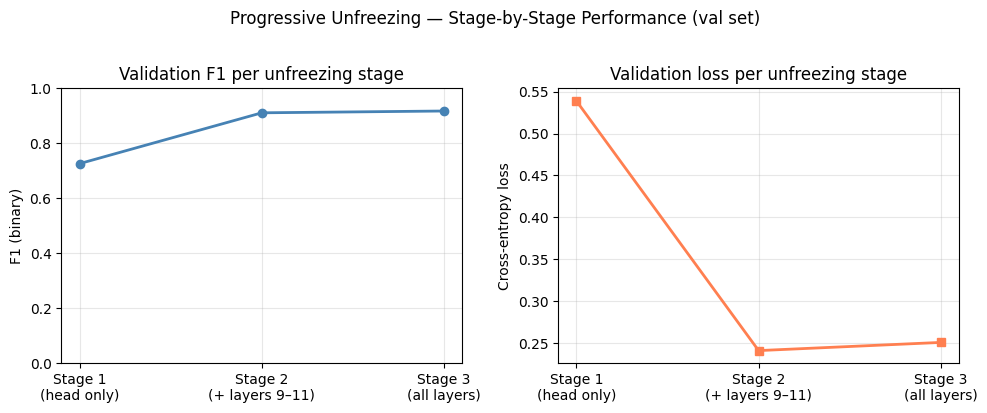

Saved: progressive_unfreeze_stages.png


In [ ]:
# Stage-by-stage comparison plot
stages     = ["Stage 1\n(head only)", "Stage 2\n(+ layers 9–11)", "Stage 3\n(all layers)"]
stage_f1   = [metrics_s1.get('eval_f1',   0), metrics_s2.get('eval_f1',   0), metrics_s3.get('eval_f1',   0)]
stage_loss = [metrics_s1.get('eval_loss', 0), metrics_s2.get('eval_loss', 0), metrics_s3.get('eval_loss', 0)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(stages, stage_f1, marker='o', linewidth=2, color='steelblue')
ax1.set_ylabel('F1 (binary)')
ax1.set_title('Validation F1 per unfreezing stage')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)

ax2.plot(stages, stage_loss, marker='s', linewidth=2, color='coral')
ax2.set_ylabel('Cross-entropy loss')
ax2.set_title('Validation loss per unfreezing stage')
ax2.grid(alpha=0.3)

plt.suptitle('Progressive Unfreezing — Stage-by-Stage Performance (val set)', y=1.02)
plt.tight_layout()
plt.savefig('progressive_unfreeze_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: progressive_unfreeze_stages.png')


## 6. Attention Visualization

We visualise attention before and after fine-tuning so we can compare the two models.

Two complementary tools are used:
* **circuitsvis** — Introduced in week 11 exercise, for interactive attention visualisation  
* **bertviz** — full head-view and model-view for BERT-style models
___

In [17]:
# ── LOAD A FINE-TUNED MODEL ─────────────────────────────────────────────────-
ARTIFACT_NAME = f"{model_name}-best-model-{VERSION}"
ARTIFACT_VERSION = "latest"

# ─────────────────────────────────────────────────────────────────────────────
LOAD_FROM_ARTIFACT = True

if LOAD_FROM_ARTIFACT:
    wandb.login()

    restore_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        job_type="inference",
        name=f"load-{ARTIFACT_NAME}",
    )

    artifact_path = f"{WANDB_ENTITY}/{WANDB_PROJECT}/{ARTIFACT_NAME}:{ARTIFACT_VERSION}"
    artifact = restore_run.use_artifact(artifact_path, type="model")
    download_dir = artifact.download()
    print(f"Artifact downloaded to: {download_dir}")

    ft_model = AutoModelForSequenceClassification.from_pretrained(download_dir).to(device)
    tokenizer = BertTokenizer.from_pretrained(download_dir)

    ft_model.eval()
    restore_run.finish()

    print("Fine-tuned model loaded from W&B Artifact.")
else:
    print("LOAD_FROM_ARTIFACT=False — using model from current training session.")

wandb: Downloading large artifact 'bert-base-cased-best-model-v04:latest', 413.84MB. 5 files...
wandb:   5 of 5 files downloaded.  
Done. 00:00:01.2 (339.3MB/s)


Artifact downloaded to: /content/artifacts/bert-base-cased-best-model-v04:v0


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Fine-tuned model loaded from W&B Artifact.


In [ ]:
# Helper: extract attention weights from any BertForSequenceClassification

# Functions from week 11 exercise
def get_bert_attention(
    bert_model,
    bert_tokenizer,
    text: str,
):
    """
    Run a forward pass with output_attentions=True.

    Returns
    -------
    tokens      : list[str]  — string tokens (including [CLS] / [SEP])
    attentions  : tuple of tensors, one per layer,
                  each shaped (1, n_heads, seq_len, seq_len)
    inputs      : the tokenizer output (for bertviz)
    """
    clean = text.replace("<br /><br />", " ")
    inputs = bert_tokenizer(
        clean, return_tensors="pt", truncation=True, max_length=256
    ).to(device)

    bert_model.eval()
    with torch.no_grad():
        outputs = bert_model(**inputs, output_attentions=True)

    # attentions: tuple of (1, n_heads, seq_len, seq_len), one per layer
    attentions = outputs.attentions
    token_ids  = inputs["input_ids"][0].tolist()
    tokens     = bert_tokenizer.convert_ids_to_tokens(token_ids)
    return tokens, attentions, inputs


# ── Helper: circuitsvis attention grid for a single layer ──

def visualize_bert_layer_circuitsvis(bert_model, bert_tokenizer, text: str, layer_id: int):
    """
    Show an interactive head-pattern grid (via circuitsvis) for one encoder layer.
    """
    tokens, attentions, _ = get_bert_attention(bert_model, bert_tokenizer, text)

    # shape: (n_heads, seq_len, seq_len)  — drop batch dim
    attn_layer = attentions[layer_id][0]  # (n_heads, seq_len, seq_len)

    print(f"Layer {layer_id} — {attn_layer.shape[0]} heads | tokens: {tokens}")
    display(
        cv.attention.attention_patterns(tokens=tokens, attention=attn_layer)
    )


# ── Helper: bertviz head-view (all layers at once) ──

def visualize_bert_bertviz(bert_model, bert_tokenizer, text: str):
    """
    Interactive bertviz head_view showing all layers simultaneously.
    """
    tokens, attentions, inputs = get_bert_attention(bert_model, bert_tokenizer, text)
    # bertviz expects a list of tensors with the batch dim present
    head_view(attentions, tokens)

### 6.1 Attention visualisation (BASE MODEL)

In [ ]:
# Pick a sample review for attention inspection
SAMPLE_POS = "This film was an absolute delight. The acting was superb and the story kept me hooked throughout."
SAMPLE_NEG = "Terrible movie. The plot made no sense and the acting was wooden and unconvincing."

# circuitsvis — layer 0
# BASE MODEL
print("=== BASE BERT | Positive review | Layer 0 ===")
visualize_bert_layer_circuitsvis(model, tokenizer, SAMPLE_POS, layer_id=0)
print("=== BASE BERT | Negative review | Layer 0 ===")
visualize_bert_layer_circuitsvis(model, tokenizer, SAMPLE_NEG, layer_id=0)

In [ ]:
# bertviz full head-view — BASE model
print("=== BASE BERT | bertviz head_view | Positive review ===")
visualize_bert_bertviz(model, tokenizer, SAMPLE_POS)

### 6.2 Attention visualisation (Fine-Tuned MODEL)

In [ ]:
# Make sure ft_model is in eval mode after training
ft_model.eval()

# circuitsvis — fine-tuned, layer 0
print("=== FINE-TUNED BERT | Positive review | Layer 0 ===")
visualize_bert_layer_circuitsvis(ft_model, tokenizer, SAMPLE_POS, layer_id=0)

print("=== FINE-TUNED BERT | Negative review | Layer 0 ===")
visualize_bert_layer_circuitsvis(ft_model, tokenizer, SAMPLE_NEG, layer_id=0)

In [ ]:
# bertviz head-view — fine-tuned model
print("=== FINE-TUNED BERT | bertviz head_view | Positive review ===")
visualize_bert_bertviz(ft_model, tokenizer, SAMPLE_POS)

In [ ]:
def mean_head_attention(bert_model, bert_tokenizer, text: str, layer_id: int):
    """
    Return the mean-over-heads attention matrix for one layer.
    Shape: (seq_len, seq_len)  —  values in [0, 1].
    """
    tokens, attentions, _ = get_bert_attention(bert_model, bert_tokenizer, text)
    # attentions[layer_id] : (1, n_heads, seq_len, seq_len)
    attn = attentions[layer_id][0]          # (n_heads, seq_len, seq_len)
    mean_attn = attn.mean(dim=0).cpu().numpy()  # (seq_len, seq_len)
    return tokens, mean_attn

def plot_cls_attention(text: str, layer_id: int = 11):
    """
    Bar chart of [CLS] attention weights (mean over heads) for base vs fine-tuned.
    """
    tokens_b, attn_b = mean_head_attention(model, tokenizer, text, layer_id)
    tokens_f, attn_f = mean_head_attention(ft_model,   tokenizer, text, layer_id)

    # Row 0 of the attention matrix = what [CLS] attends to
    cls_b = attn_b[0]
    cls_f = attn_f[0]

    x = np.arange(len(tokens_b))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(tokens_b) * 0.5), 4))
    ax.bar(x - width / 2, cls_b, width, label="Base BERT",        color="steelblue", alpha=0.8)
    ax.bar(x + width / 2, cls_f, width, label="Fine-tuned BERT",  color="coral",     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(tokens_b, rotation=60, ha="right", fontsize=9)
    ax.set_ylabel("[CLS] attention weight (mean over heads)")
    ax.set_title(f"[CLS] Attention — Layer {layer_id}")
    ax.legend()
    plt.tight_layout()
    plt.show()


print("Positive review — last layer")
plot_cls_attention(SAMPLE_POS, layer_id=11)

print("Negative review — last layer")
plot_cls_attention(SAMPLE_NEG, layer_id=11)

### 6.3 Side by Side comparison

In [ ]:
CUSTOM_TEXT = "I wasn't sure about this film at first but it completely won me over by the end."
LAYER       = 5          # 0–11 for bert-base

print("── circuitsvis: Base BERT ──")
visualize_bert_layer_circuitsvis(model, tokenizer, CUSTOM_TEXT, LAYER)

print("── circuitsvis: Fine-tuned BERT ──")
visualize_bert_layer_circuitsvis(ft_model, tokenizer, CUSTOM_TEXT, LAYER)

print("── [CLS] attention bar chart ──")
plot_cls_attention(CUSTOM_TEXT, layer_id=LAYER)

### Load a finetuned wandb model from checkpoint

In [ ]:
CKPT = "./results/checkpoint-4221"   # epoch 3  --- DEFINE YOUR CHECKPOINT
# or "./results/checkpoint-1407"     # epoch 1

# Note: the pretrained_model has a random classifier head, so use it mostly for attention/representation comparison,
# not final classification performance.
pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    output_attentions=True,
    output_hidden_states=True,
    attn_implementation="eager"
).to(device)

finetuned_model = AutoModelForSequenceClassification.from_pretrained(
    CKPT,
    output_attentions=True,
    output_hidden_states=True
).to(device)

pretrained_model.eval()
finetuned_model.eval()

#### Use finetuned model to predict on test set

In [18]:
label_names = {0: "negative", 1: "positive"}

def predict_dataset(model, dataset, tokenizer, device, max_length=256, batch_size=16):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []
    all_texts = []

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i + batch_size]

        texts = [t.replace("<br /><br />", " ") for t in batch["text"]]
        labels = batch["label"]

        inputs = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        )

        # move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)

        preds = torch.argmax(probs, dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_probs.extend(probs.cpu().numpy())
        all_texts.extend(texts)

    results_df = pd.DataFrame({
        "text": all_texts,
        "true_label": all_labels,
        "pred_label": all_preds,
        "prob_negative": [p[0] for p in all_probs],
        "prob_positive": [p[1] for p in all_probs],
    })

    results_df["correct"] = results_df["true_label"] == results_df["pred_label"]
    results_df["confidence"] = results_df[["prob_negative", "prob_positive"]].max(axis=1)

    return results_df

In [ ]:
test_predictions = predict_dataset(
    model=ft_model,          # loaded from W&B artifact
    dataset=dataset_test,
    tokenizer=tokenizer,
    device=device,
    max_length=256,
    batch_size=16
)

test_predictions.to_csv("test_predictions.csv", index=False)
test_predictions.head()

In [ ]:
# Load file, if you havn't run the above
test_predictions = pd.read_csv("test_predictions.csv")

In [ ]:
# overall accuracy
accuracy = (test_predictions["correct"]).mean()
print("Accuracy:", accuracy)

# class distribution in predictions
print(test_predictions["pred_label"].value_counts())

# class distribution in ground truth
print(test_predictions["true_label"].value_counts())

#### Edge cases

In [ ]:
# Get misclassified examples from the dataset
wrong_predictions = test_predictions[test_predictions["correct"] == False]

wrong_predictions[[
    "true_label",
    "pred_label",
    "confidence",
    "prob_negative",
    "prob_positive",
    "text"
]].head()

In [ ]:
# Find confident mistakes
confident_wrong = wrong_predictions.sort_values(
    "confidence",
    ascending=False
)

confident_wrong[[
    "true_label",
    "pred_label",
    "confidence",
    "prob_negative",
    "prob_positive",
    "text"
]].head()

In [ ]:
# high-confidence wrong predictions
edge_cases = confident_wrong.head().copy()     # where model fails badly

# low-confidence / ambiguous predictions
uncertain_cases = test_predictions.sort_values("confidence").head().copy()     # ambiguous cases

# examples with contrast words
contrast_cases = test_predictions[
    test_predictions["text"].str.contains(r"\bbut\b|\bhowever\b|\balthough\b", case=False, regex=True)
].head()

# examples with negation
negation_cases = test_predictions[
    test_predictions["text"].str.contains(r"\bnot\b|n't|\bnever\b|\bno\b", case=False, regex=True)
].head()

#### Choose your cases

In [ ]:
row = confident_wrong.iloc[0] # most wrong classification
row['text']

#### Show what [CLS] attends to

In [ ]:
def cls_top_tokens(row, model, tokenizer, layer=11, head=0, top_k=15, max_length=256):
    text = row["text"]

    inputs = tokenizer(
        text,
        truncation=True,
        padding=False,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        pred_label = int(torch.argmax(probs).cpu())

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())
    attention = outputs.attentions[layer][0, head].detach().cpu().numpy()

    cls_attention = attention[0]  # attention from [CLS] to all tokens
    top_idx = cls_attention.argsort()[-top_k:][::-1]

    return pd.DataFrame({
        "token": [tokens[i] for i in top_idx],
        "attention_from_CLS": [float(cls_attention[i]) for i in top_idx],
        "layer": layer,
        "head": head,
        "true_label": label_names[int(row["true_label"])],
        "pred_label": label_names[pred_label],
        "prob_negative": float(probs[0].cpu()),
        "prob_positive": float(probs[1].cpu())
    })

In [ ]:
cls_top_tokens(
    row,
    finetuned_model,
    tokenizer,
    layer=11,
    head=0
)

### Scan many heads to find sentiment-sensitive ones

In [ ]:
# https://www.kaggle.com/datasets/prajwalkanade/sentiment-analysis-word-lists-dataset
sentiment_keywords = [
    "absurd", "awful", "addicted", "annoying", "amazing",
    "bad", "best", "brilliant", "boring", "bleak",
    "care", "cheap",
    "excellent",
    "good", "great",
    "hate", "hated",
    "liked", "love", "loved",
    "underwhealming"
    "terrible",
    "worst",  "waste", "poor",
    "but", "not", "never", "no", "however",
]

def score_head_for_keywords(row, model, tokenizer, layer, head, keywords, max_length=256):
    text = row["text"]

    inputs = tokenizer(
        text,
        truncation=True,
        padding=False,
        max_length=max_length,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].cpu())
    attention = outputs.attentions[layer][0, head].detach().cpu().numpy()
    cls_attention = attention[0]

    score = 0.0
    matched = []

    for i, tok in enumerate(tokens):
        clean_tok = tok.replace("##", "").lower()
        if clean_tok in keywords:
            score += float(cls_attention[i])
            matched.append(tok)

    return score, matched

def scan_heads_for_example(row, model, tokenizer, keywords=sentiment_keywords):
    # “How much does this head focus on sentiment words?”
    rows = []

    for layer in range(model.config.num_hidden_layers):
        for head in range(model.config.num_attention_heads):
            score, matched = score_head_for_keywords(
                row, model, tokenizer, layer, head, keywords
            )
            rows.append({
                "layer": layer,
                "head": head,
                "sentiment_attention_score": score, # sum of attention from [CLS] → sentiment-related tokens
                "matched_tokens": matched
            })

    return pd.DataFrame(rows).sort_values(
        "sentiment_attention_score",
        ascending=False
    )

In [ ]:
head_scores = scan_heads_for_example(
    confident_wrong.iloc[0],    # or "row"
    finetuned_model,
    tokenizer
)

head_scores.head()

In [ ]:
uncertain_cases